In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_bug_cumsum(cov_df, bug_df):
    y_val = pd.Series(0, index=cov_df["total_inputs"])
    bug_counts = bug_df["iteration"].value_counts()
    y_val.update(bug_counts)
    return y_val.cumsum()

## 1. JSON

In [2]:
bug_json_df_wy = pd.read_csv("json/json_decoder_bugs_wy.csv")
cov_json_df_wy = pd.read_csv("json/json_decoder_coverage_wy.csv")

bug_json_df_jan = pd.read_csv("json/json_decoder_bugs_jan.csv")
cov_json_df_jan = pd.read_csv("json/json_decoder_coverage_jan.csv")

bug_json_df_nat = pd.read_csv("json/json_decoder_bugs_nat.csv")
cov_json_df_nat = pd.read_csv("json/json_decoder_coverage_nat.csv")

bug_json_df_zx = pd.read_csv("json/json_decoder_bugs_zx.csv")
cov_json_df_zx = pd.read_csv("json/json_decoder_coverage_zx.csv")

bug_json_df_sel = pd.read_csv("json/json_decoder_bugs_sel.csv")
cov_json_df_sel = pd.read_csv("json/json_decoder_coverage_sel.csv")


### RQ1: Effectiveness - Unique Bugs vs Total Inputs

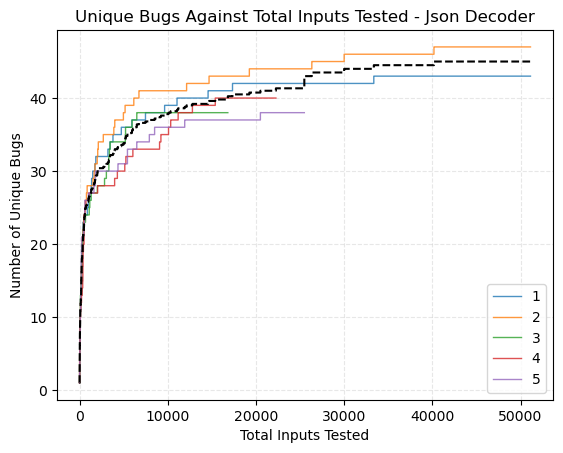

In [3]:
json_cumsum_wy = get_bug_cumsum(cov_json_df_wy, bug_json_df_wy)
json_cumsum_jan = get_bug_cumsum(cov_json_df_jan, bug_json_df_jan)
json_cumsum_nat = get_bug_cumsum(cov_json_df_nat, bug_json_df_nat)
json_cumsum_zx = get_bug_cumsum(cov_json_df_zx, bug_json_df_zx)
json_cumsum_sel = get_bug_cumsum(cov_json_df_sel, bug_json_df_sel)

df_rq1_json = pd.DataFrame({
    "1": json_cumsum_wy,
    "2": json_cumsum_jan,
    "3": json_cumsum_nat,
    "4": json_cumsum_zx,
    "5": json_cumsum_sel,
}, index=cov_json_df_jan["total_inputs"])

df_rq1_json['AVERAGE'] = df_rq1_json.mean(axis=1)

ax = df_rq1_json.drop(columns=['AVERAGE']).plot(
    drawstyle="steps-post", 
    alpha=0.8, 
    linewidth=1
)
df_rq1_json['AVERAGE'].plot(
    ax=ax, 
    drawstyle="steps-post", 
    color='black', 
    linewidth=1.5, 
    label='Mean Performance',
    linestyle='--'
)

ax.set_axisbelow(True)
plt.xlabel("Total Inputs Tested")
plt.ylabel("Number of Unique Bugs")
plt.title("Unique Bugs Against Total Inputs Tested - Json Decoder")
plt.grid(True, linestyle='--', alpha=0.3)

### RQ1: Effectiveness - Coverage vs Time

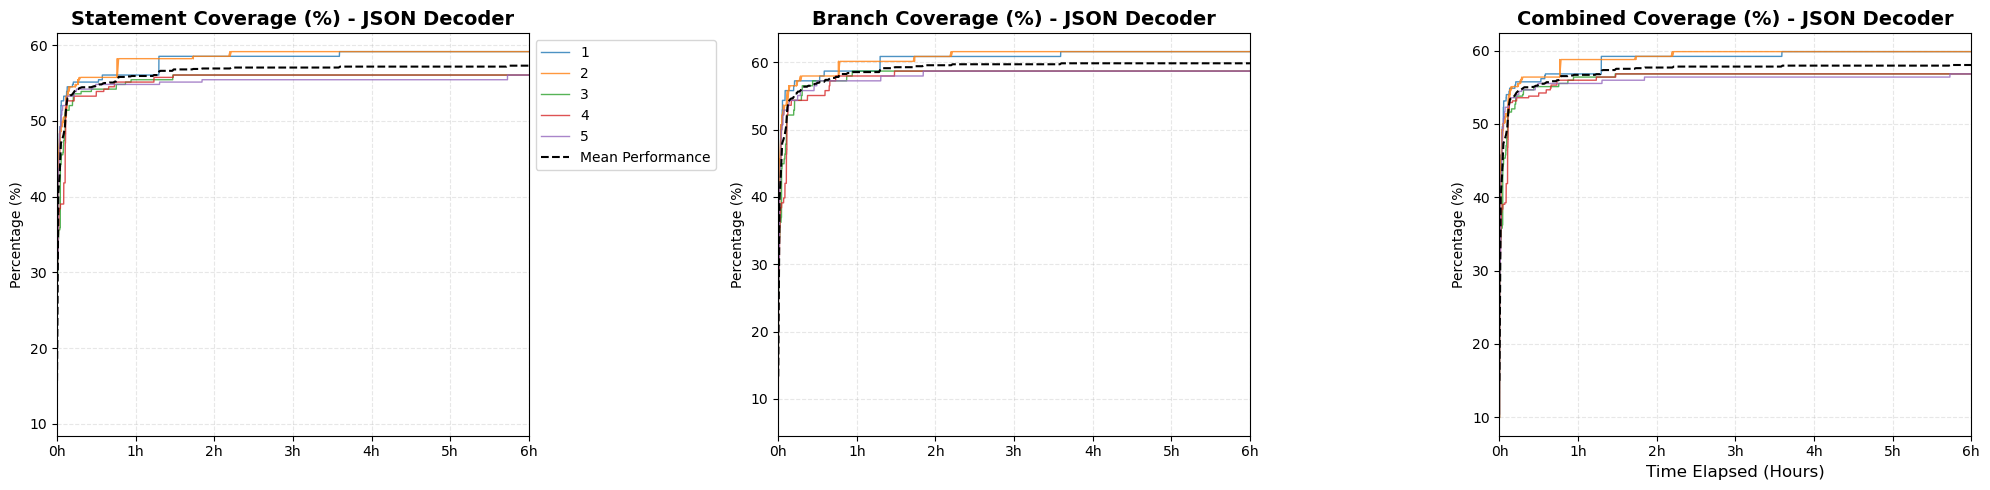

In [4]:
runs = {
    "1": cov_json_df_wy,
    "2": cov_json_df_jan,
    "3": cov_json_df_nat,
    "4": cov_json_df_zx,
    "5": cov_json_df_sel
}

metrics = {
    "statement_coverage": "Statement Coverage (%)",
    "branch_coverage": "Branch Coverage (%)",
    "function_coverage": "Combined Coverage (%)"
}

common_time_grid = np.linspace(0, 6, 361)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (col, title) in enumerate(metrics.items()):
    ax = axes[i]
    all_interpolated_values = []
    
    for name, df in runs.items():
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', dayfirst=True)
        df = df.sort_values('timestamp')
        
        start_time = df['timestamp'].iloc[0]
        elapsed_hours = (df['timestamp'] - start_time).dt.total_seconds() / 3600
        
        ax.plot(elapsed_hours, df[col], alpha=0.8, linewidth=1, label=name)
        
        interp_vals = np.interp(common_time_grid, elapsed_hours, df[col])
        all_interpolated_values.append(interp_vals)
    
    mean_performance = np.mean(all_interpolated_values, axis=0)
    
    ax.plot(
        common_time_grid, 
        mean_performance, 
        color='black', 
        linestyle='--', 
        linewidth=1.5, 
        label='Mean Performance'
    )
    
    ax.set_axisbelow(True)
    ax.set_title(title + " - JSON Decoder", fontweight='bold', fontsize=14)
    ax.set_ylabel("Percentage (%)")
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(0, 6)
    ax.set_xticks(range(7))
    ax.set_xticklabels([f"{h}h" for h in range(7)])

axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

axes[2].set_xlabel("Time Elapsed (Hours)", fontsize=12)

plt.tight_layout()
plt.show()

### RQ4: Stability

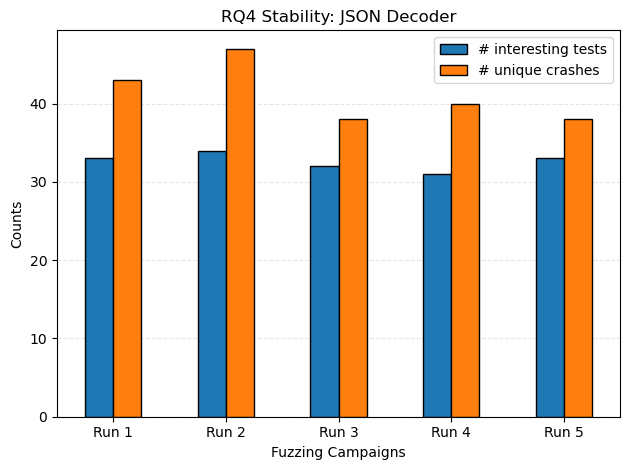

In [5]:
df_rq4_json = pd.DataFrame({
    'Session': ["Run 1", "Run 2", "Run 3", "Run 4", "Run 5"],
    'Interesting Inputs': [33, 34, 32, 31, 33],
    'Unique Bugs': [43, 47, 38, 40, 38]
})

ax = df_rq4_json.plot(x='Session', kind='bar', rot=0, edgecolor='black')
ax.set_axisbelow(True)
plt.title("RQ4 Stability: JSON Decoder")
plt.ylabel("Counts")
plt.xlabel("Fuzzing Campaigns")
plt.legend(["# interesting tests", "# unique crashes"])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Cidrize

In [6]:
bug_cidr_df_wy = pd.read_csv("cidrize/cidrize_bugs_wy.csv")
cov_cidr_df_wy = pd.read_csv("cidrize/cidrize_coverage_wy.csv")

bug_cidr_df_jan = pd.read_csv("cidrize/cidrize_bugs_jan.csv")
cov_cidr_df_jan = pd.read_csv("cidrize/cidrize_coverage_jan.csv")

bug_cidr_df_nat = pd.read_csv("cidrize/cidrize_bugs_nat.csv")
cov_cidr_df_nat = pd.read_csv("cidrize/cidrize_coverage_nat.csv")

bug_cidr_df_zx = pd.read_csv("cidrize/cidrize_bugs_zx.csv")
cov_cidr_df_zx = pd.read_csv("cidrize/cidrize_coverage_zx.csv")

bug_cidr_df_sel = pd.read_csv("cidrize/cidrize_bugs_sel.csv")
cov_cidr_df_sel = pd.read_csv("cidrize/cidrize_coverage_sel.csv")

### RQ1: Unique Bugs vs Total Inputs

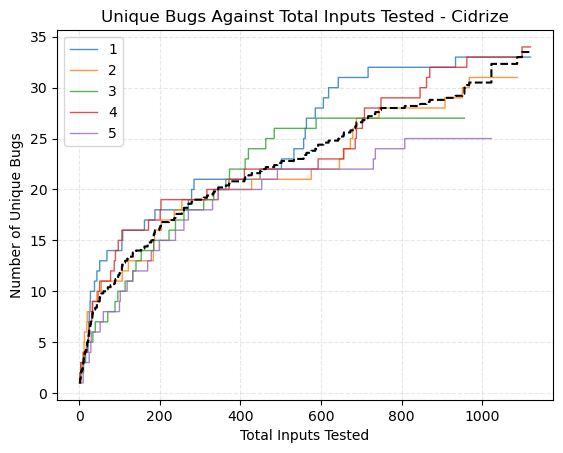

In [18]:
cidr_cumsum_wy = get_bug_cumsum(cov_cidr_df_wy, bug_cidr_df_wy)
cidr_cumsum_jan = get_bug_cumsum(cov_cidr_df_jan, bug_cidr_df_jan)
cidr_cumsum_nat = get_bug_cumsum(cov_cidr_df_nat, bug_cidr_df_nat)
cidr_cumsum_zx = get_bug_cumsum(cov_cidr_df_zx, bug_cidr_df_zx)
cidr_cumsum_sel = get_bug_cumsum(cov_cidr_df_sel, bug_cidr_df_sel)

df_rq1_cidr = pd.DataFrame({
    "1": cidr_cumsum_wy,
    "2": cidr_cumsum_jan,
    "3": cidr_cumsum_nat,
    "4": cidr_cumsum_zx,
    "5": cidr_cumsum_sel,
}, index=cov_cidr_df_wy["total_inputs"])

df_rq1_cidr['AVERAGE'] = df_rq1_cidr.mean(axis=1)

ax = df_rq1_cidr.drop(columns=['AVERAGE']).plot(
    drawstyle="steps-post", 
    alpha=0.8, 
    linewidth=1
)
df_rq1_cidr['AVERAGE'].plot(
    ax=ax, 
    drawstyle="steps-post", 
    color='black', 
    linewidth=1.5, 
    label='Mean Performance',
    linestyle='--'
)

ax.set_axisbelow(True)
plt.xlabel("Total Inputs Tested")
plt.ylabel("Number of Unique Bugs")
plt.title("Unique Bugs Against Total Inputs Tested - Cidrize")
plt.grid(True, linestyle='--', alpha=0.3)

### RQ1: Effectiveness - Coverage vs Time

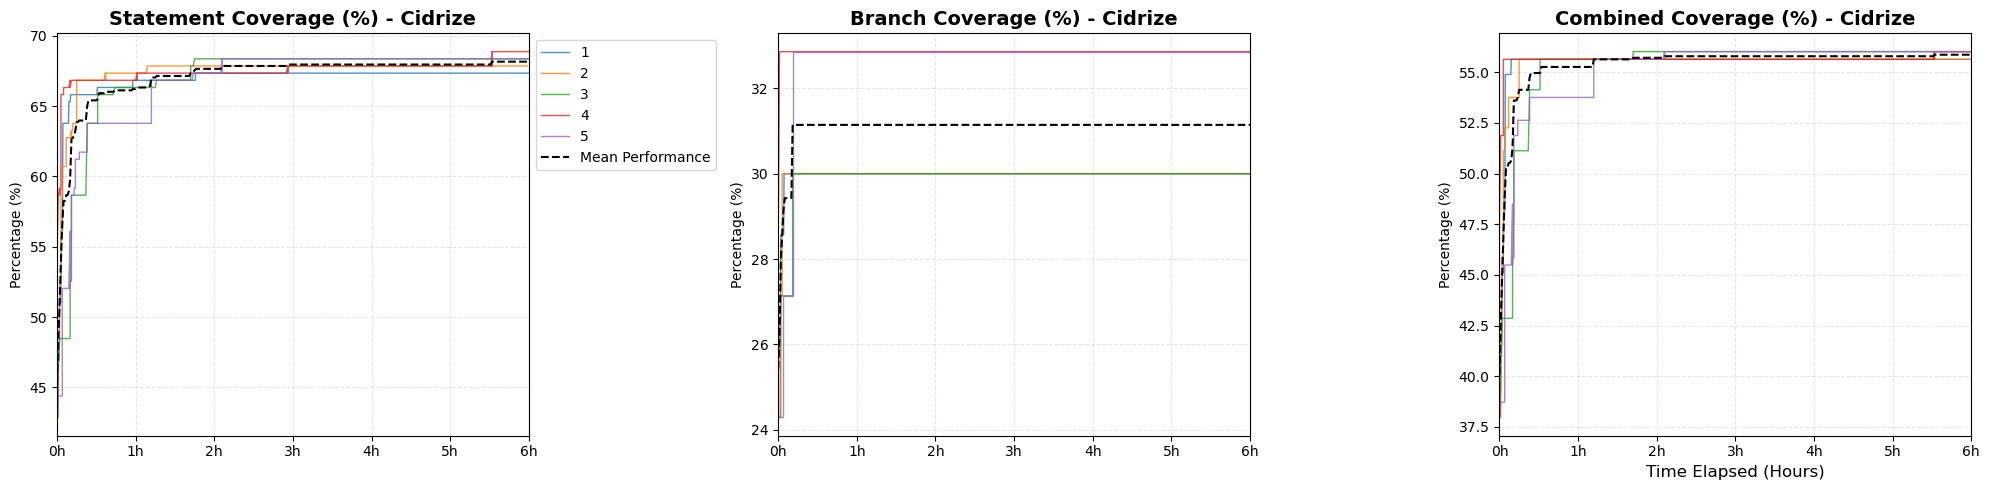

In [8]:
runs = {
    "1": cov_cidr_df_wy,
    "2": cov_cidr_df_jan,
    "3": cov_cidr_df_nat,
    "4": cov_cidr_df_zx,
    "5": cov_cidr_df_sel
}

metrics = {
    "statement_coverage": "Statement Coverage (%)",
    "branch_coverage": "Branch Coverage (%)",
    "function_coverage": "Combined Coverage (%)"
}

common_time_grid = np.linspace(0, 6, 361)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (col, title) in enumerate(metrics.items()):
    ax = axes[i]
    all_interpolated_values = []
    
    for name, df in runs.items():
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', dayfirst=True)
        df = df.sort_values('timestamp')
        
        start_time = df['timestamp'].iloc[0]
        elapsed_hours = (df['timestamp'] - start_time).dt.total_seconds() / 3600
        
        ax.plot(elapsed_hours, df[col], alpha=0.8, linewidth=1, label=name)
        
        interp_vals = np.interp(common_time_grid, elapsed_hours, df[col])
        all_interpolated_values.append(interp_vals)
    
    mean_performance = np.mean(all_interpolated_values, axis=0)
    
    ax.plot(
        common_time_grid, 
        mean_performance, 
        color='black', 
        linestyle='--', 
        linewidth=1.5, 
        label='Mean Performance'
    )
    
    ax.set_axisbelow(True)
    ax.set_title(title  + " - Cidrize", fontweight='bold', fontsize=14)
    ax.set_ylabel("Percentage (%)")
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(0, 6)
    ax.set_xticks(range(7))
    ax.set_xticklabels([f"{h}h" for h in range(7)])

axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

axes[2].set_xlabel("Time Elapsed (Hours)", fontsize=12)

plt.tight_layout()
plt.show()

### RQ4: Stability

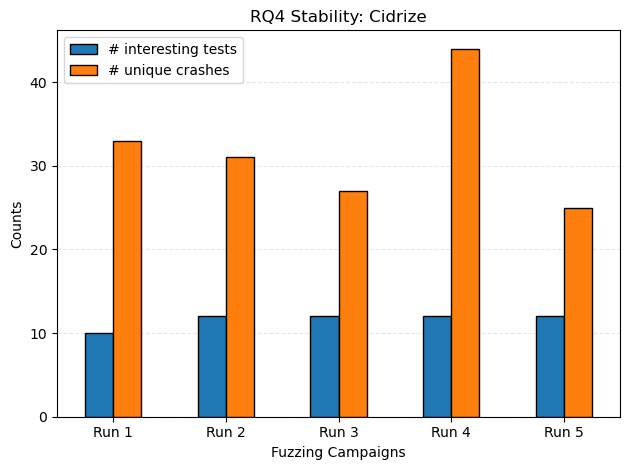

In [9]:
df_rq4_cidr = pd.DataFrame({
    'Session': ["Run 1", "Run 2", "Run 3", "Run 4", "Run 5"],
    'Interesting Inputs': [10, 12, 12, 12, 12],
    'Unique Bugs': [33, 31, 27, 44, 25]
})

ax = df_rq4_cidr.plot(x='Session', kind='bar', rot=0, edgecolor='black')
ax.set_axisbelow(True)
plt.title("RQ4 Stability: Cidrize")
plt.ylabel("Counts")
plt.xlabel("Fuzzing Campaigns")
plt.legend(["# interesting tests", "# unique crashes"])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. IPV4

In [10]:
bug_ipv4_df_wy = pd.read_csv("ipv4/ipv4_parser_bugs_wy.csv")
cov_ipv4_df_wy = pd.read_csv("ipv4/ipv4_parser_coverage_wy.csv")

bug_ipv4_df_jan = pd.read_csv("ipv4/ipv4_parser_bugs_jan.csv")
cov_ipv4_df_jan = pd.read_csv("ipv4/ipv4_parser_coverage_jan.csv")

bug_ipv4_df_sel = pd.read_csv("ipv4/ipv4_parser_bugs_sel.csv")
cov_ipv4_df_sel = pd.read_csv("ipv4/ipv4_parser_coverage_sel.csv")

bug_ipv4_df_zx = pd.read_csv("ipv4/ipv4_parser_bugs_zx.csv")
cov_ipv4_df_zx = pd.read_csv("ipv4/ipv4_parser_coverage_zx.csv")

bug_ipv4_df_nat = pd.read_csv("ipv4/ipv4_parser_bugs_nat.csv")
cov_ipv4_df_nat = pd.read_csv("ipv4/ipv4_parser_coverage_nat.csv")

### RQ1: Unique Bugs vs Total Inputs

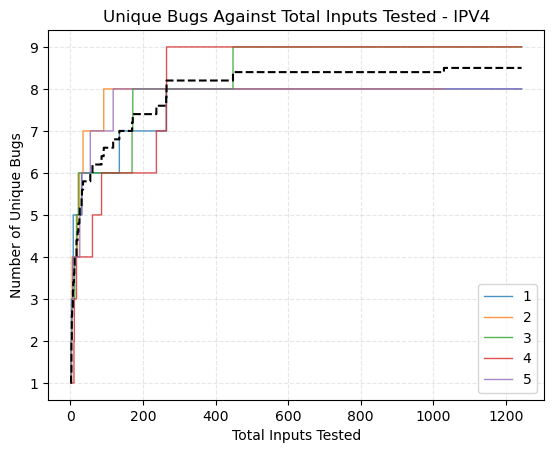

In [20]:
ipv4_cumsum_wy = get_bug_cumsum(cov_ipv4_df_wy, bug_ipv4_df_wy)
ipv4_cumsum_jan = get_bug_cumsum(cov_ipv4_df_jan, bug_ipv4_df_jan)
ipv4_cumsum_nat = get_bug_cumsum(cov_ipv4_df_nat, bug_ipv4_df_nat)
ipv4_cumsum_zx = get_bug_cumsum(cov_ipv4_df_zx, bug_ipv4_df_zx)
ipv4_cumsum_sel = get_bug_cumsum(cov_ipv4_df_sel, bug_ipv4_df_sel)

df_rq1_ipv4 = pd.DataFrame({
    "1": ipv4_cumsum_wy,
    "2": ipv4_cumsum_jan,
    "3": ipv4_cumsum_nat,
    "4": ipv4_cumsum_zx,
    "5": ipv4_cumsum_sel,
}, index=cov_ipv4_df_nat["total_inputs"])

df_rq1_ipv4['AVERAGE'] = df_rq1_ipv4.mean(axis=1)

ax = df_rq1_ipv4.drop(columns=['AVERAGE']).plot(
    drawstyle="steps-post", 
    alpha=0.8, 
    linewidth=1
)
df_rq1_ipv4['AVERAGE'].plot(
    ax=ax, 
    drawstyle="steps-post", 
    color='black', 
    linewidth=1.5, 
    label='Mean Performance',
    linestyle='--'
)

ax.set_axisbelow(True)
plt.xlabel("Total Inputs Tested")
plt.ylabel("Number of Unique Bugs")
plt.title("Unique Bugs Against Total Inputs Tested - IPV4")
plt.grid(True, linestyle='--', alpha=0.3)

### RQ1: Effectiveness - Coverage vs Time

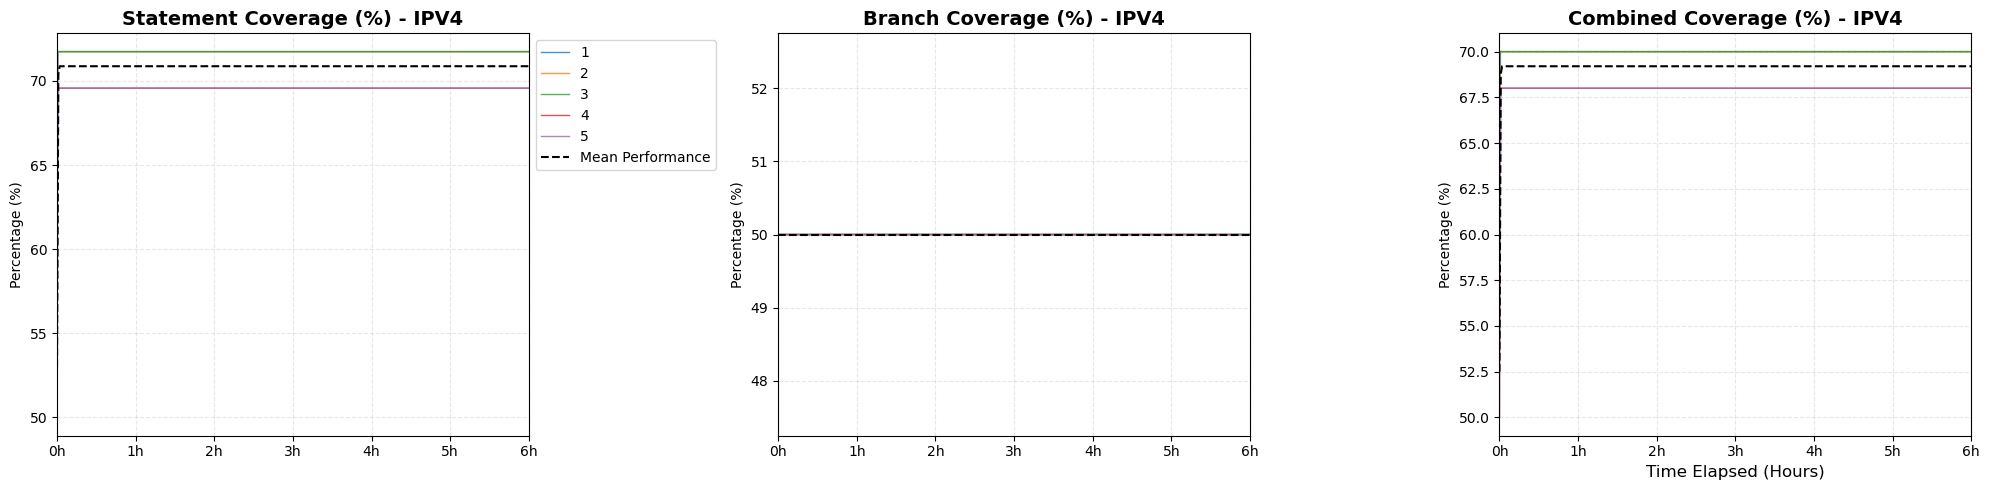

In [12]:
runs = {
    "1": cov_ipv4_df_wy,
    "2": cov_ipv4_df_jan,
    "3": cov_ipv4_df_nat,
    "4": cov_ipv4_df_zx,
    "5": cov_ipv4_df_sel
}

metrics = {
    "statement_coverage": "Statement Coverage (%)",
    "branch_coverage": "Branch Coverage (%)",
    "function_coverage": "Combined Coverage (%)"
}

common_time_grid = np.linspace(0, 6, 361)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (col, title) in enumerate(metrics.items()):
    ax = axes[i]
    all_interpolated_values = []
    
    for name, df in runs.items():
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', dayfirst=True)
        df = df.sort_values('timestamp')
        
        start_time = df['timestamp'].iloc[0]
        elapsed_hours = (df['timestamp'] - start_time).dt.total_seconds() / 3600
        
        ax.plot(elapsed_hours, df[col], alpha=0.8, linewidth=1, label=name)
        
        interp_vals = np.interp(common_time_grid, elapsed_hours, df[col])
        all_interpolated_values.append(interp_vals)
    
    mean_performance = np.mean(all_interpolated_values, axis=0)
    
    ax.plot(
        common_time_grid, 
        mean_performance, 
        color='black', 
        linestyle='--', 
        linewidth=1.5, 
        label='Mean Performance'
    )
    
    ax.set_axisbelow(True)
    ax.set_title(title  + " - IPV4", fontweight='bold', fontsize=14)
    ax.set_ylabel("Percentage (%)")
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(0, 6)
    ax.set_xticks(range(7))
    ax.set_xticklabels([f"{h}h" for h in range(7)])

axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

axes[2].set_xlabel("Time Elapsed (Hours)", fontsize=12)

plt.tight_layout()
plt.show()

### RQ4: Stability

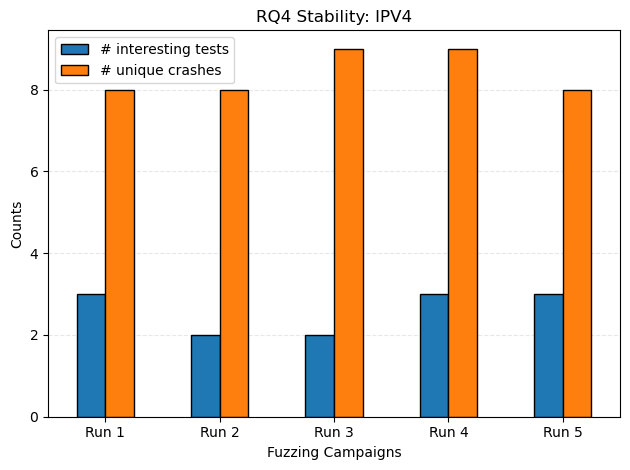

In [13]:
df_rq4_ipv4 = pd.DataFrame({
    'Session': ["Run 1", "Run 2", "Run 3", "Run 4", "Run 5"],
    'Interesting Inputs': [3, 2, 2, 3, 3],
    'Unique Bugs': [8, 8, 9, 9, 8]
})

ax = df_rq4_ipv4.plot(x='Session', kind='bar', rot=0, edgecolor='black')
ax.set_axisbelow(True)
plt.title("RQ4 Stability: IPV4")
plt.ylabel("Counts")
plt.xlabel("Fuzzing Campaigns")
plt.legend(["# interesting tests", "# unique crashes"])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. IPV6

In [14]:
bug_ipv6_df_wy = pd.read_csv("ipv6/ipv6_parser_bugs_wy.csv")
cov_ipv6_df_wy = pd.read_csv("ipv6/ipv6_parser_coverage_wy.csv")

bug_ipv6_df_jan = pd.read_csv("ipv6/ipv6_parser_bugs_jan.csv")
cov_ipv6_df_jan = pd.read_csv("ipv6/ipv6_parser_coverage_jan.csv")

bug_ipv6_df_sel = pd.read_csv("ipv6/ipv6_parser_bugs_sel.csv")
cov_ipv6_df_sel = pd.read_csv("ipv6/ipv6_parser_coverage_sel.csv")

bug_ipv6_df_zx = pd.read_csv("ipv6/ipv6_parser_bugs_zx.csv")
cov_ipv6_df_zx = pd.read_csv("ipv6/ipv6_parser_coverage_zx.csv")

bug_ipv6_df_nat = pd.read_csv("ipv6/ipv6_parser_bugs_nat.csv")
cov_ipv6_df_nat = pd.read_csv("ipv6/ipv6_parser_coverage_nat.csv")

### RQ1: Unique Bugs vs Total Inputs

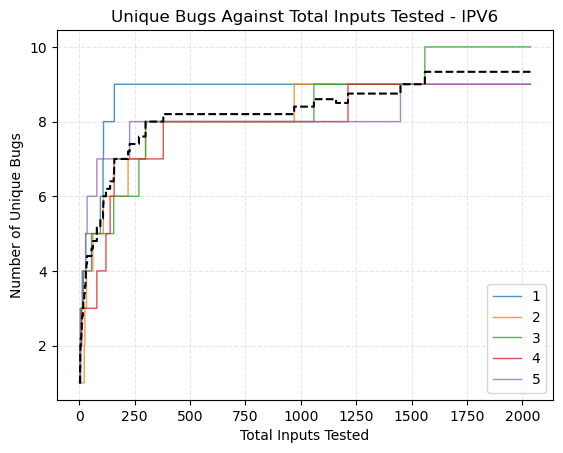

In [21]:
ipv6_cumsum_wy = get_bug_cumsum(cov_ipv6_df_wy, bug_ipv6_df_wy)
ipv6_cumsum_jan = get_bug_cumsum(cov_ipv6_df_jan, bug_ipv6_df_jan)
ipv6_cumsum_nat = get_bug_cumsum(cov_ipv6_df_nat, bug_ipv6_df_nat)
ipv6_cumsum_zx = get_bug_cumsum(cov_ipv6_df_zx, bug_ipv6_df_zx)
ipv6_cumsum_sel = get_bug_cumsum(cov_ipv6_df_sel, bug_ipv6_df_sel)

df_rq1_ipv6 = pd.DataFrame({
    "1": ipv6_cumsum_wy,
    "2": ipv6_cumsum_jan,
    "3": ipv6_cumsum_nat,
    "4": ipv6_cumsum_zx,
    "5": ipv6_cumsum_sel,
}, index=cov_ipv6_df_nat["total_inputs"])

df_rq1_ipv6['AVERAGE'] = df_rq1_ipv6.mean(axis=1)

ax = df_rq1_ipv6.drop(columns=['AVERAGE']).plot(
    drawstyle="steps-post", 
    alpha=0.8, 
    linewidth=1
)
df_rq1_ipv6['AVERAGE'].plot(
    ax=ax, 
    drawstyle="steps-post", 
    color='black', 
    linewidth=1.5, 
    label='Mean Performance',
    linestyle='--'
)

ax.set_axisbelow(True)
plt.xlabel("Total Inputs Tested")
plt.ylabel("Number of Unique Bugs")
plt.title("Unique Bugs Against Total Inputs Tested - IPV6")
plt.grid(True, linestyle='--', alpha=0.3)

### RQ1: Effectiveness - Coverage vs Time

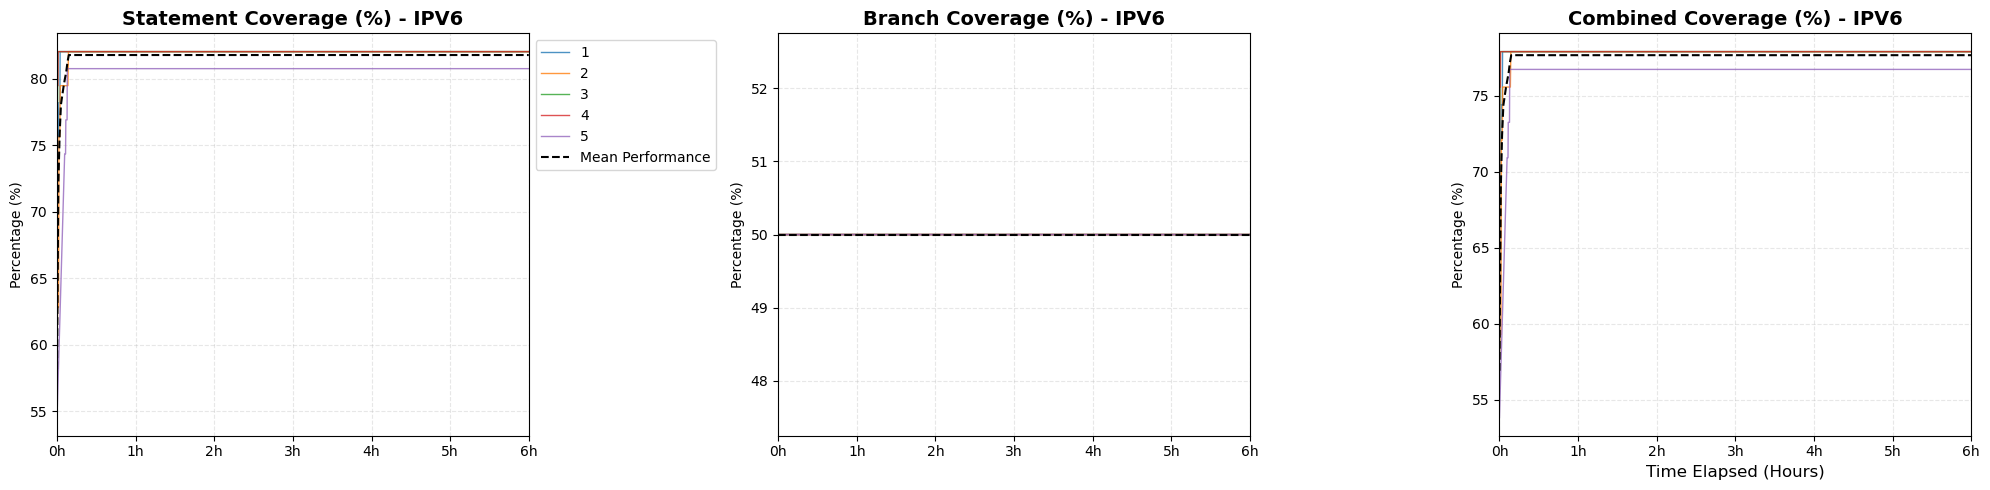

In [16]:
runs = {
    "1": cov_ipv6_df_wy,
    "2": cov_ipv6_df_jan,
    "3": cov_ipv6_df_nat,
    "4": cov_ipv6_df_zx,
    "5": cov_ipv6_df_sel
}

metrics = {
    "statement_coverage": "Statement Coverage (%)",
    "branch_coverage": "Branch Coverage (%)",
    "function_coverage": "Combined Coverage (%)"
}

common_time_grid = np.linspace(0, 6, 361)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (col, title) in enumerate(metrics.items()):
    ax = axes[i]
    all_interpolated_values = []
    
    for name, df in runs.items():
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', dayfirst=True)
        df = df.sort_values('timestamp')
        
        start_time = df['timestamp'].iloc[0]
        elapsed_hours = (df['timestamp'] - start_time).dt.total_seconds() / 3600
        
        ax.plot(elapsed_hours, df[col], alpha=0.8, linewidth=1, label=name)
        
        interp_vals = np.interp(common_time_grid, elapsed_hours, df[col])
        all_interpolated_values.append(interp_vals)
    
    mean_performance = np.mean(all_interpolated_values, axis=0)
    
    ax.plot(
        common_time_grid, 
        mean_performance, 
        color='black', 
        linestyle='--', 
        linewidth=1.5, 
        label='Mean Performance'
    )
    
    ax.set_axisbelow(True)
    ax.set_title(title  + " - IPV6", fontweight='bold', fontsize=14)
    ax.set_ylabel("Percentage (%)")
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(0, 6)
    ax.set_xticks(range(7))
    ax.set_xticklabels([f"{h}h" for h in range(7)])

axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

axes[2].set_xlabel("Time Elapsed (Hours)", fontsize=12)

plt.tight_layout()
plt.show()

### RQ4: Stability

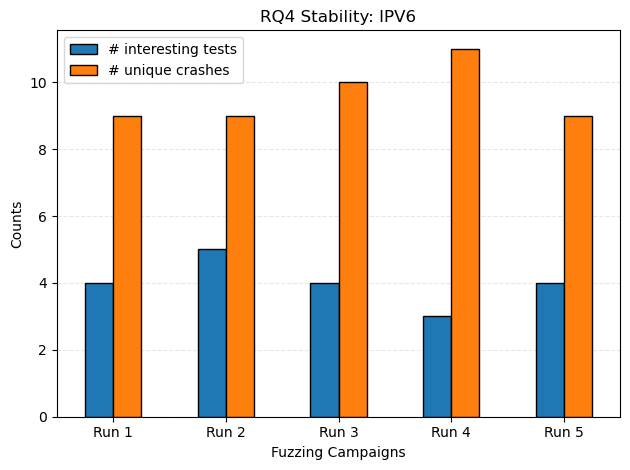

In [17]:
df_rq4_ipv6 = pd.DataFrame({
    'Session': ["Run 1", "Run 2", "Run 3", "Run 4", "Run 5"],
    'Seed Corpus': [4, 5, 4, 3, 4],
    'Unique Bugs': [9, 9, 10, 11, 9]
})

ax = df_rq4_ipv6.plot(x='Session', kind='bar', rot=0, edgecolor='black')
ax.set_axisbelow(True)
plt.title("RQ4 Stability: IPV6")
plt.ylabel("Counts")
plt.xlabel("Fuzzing Campaigns")
plt.legend(["# interesting tests", "# unique crashes"])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()